Compte-rendu du projet d'informatique de modélisation du réseau de transport ferroviaire de Montréal
TIPE CPGE 2022-2023 : La Ville

L'objectif de ce compte-rendu est de présenter la simulation du réseau ferroviaire de Montréal, montrez la pertinence des hypothèses, et la précision des résultats par rapport aux données disponibles sur les temps de transport réels.

Le projet se décompose en plusieurs parties :
- Fonctions de parcours de graphe : détermination de l'algorithme le plus performant
- Programmation orientée objet : création des différentes classes File, Train, Station, Ligne, Voyageur
- Création du réseau ferroviaire de Montréal
- Exécution de la simulation
- Analyse des résultats de la simulation

In [2]:
import numpy as np
import random as rd
import time
import collections as co
import matplotlib.pyplot as plt
from IPython.display import Image, display
import re

In [3]:
lecteur = True #Pour les lecteurs consultant le code, les images liées à l'exécution du code (exécution assez longue) sont déjà disponibles dans le dossier images

___
## Fonctions pour parcours de graphe : algorithmes de plus court chemin

In [4]:
def symetrisation(Mat): #Transforme une matrice de graphe orienté en une matrice de graphe non orienté en recopiant la triangle supérieure dans la triangle inférieure
    N = len(Mat)
    for lig in range(N):
        for col in range(N):
            Mat[col,lig]=Mat[lig,col]

def voisins(x,G): #Dans un graphe orienté, les voisins d'un sommet x sont les sommets atteignables immédiatement par x dans G
    n = np.shape(G)[0]
    S = []
    for i in range (n):
        if G[x,i] != 0 and i != x:
            S.append(i)
    return(S)

def antecedents(x,G): #Dans un graphe orienté, les antécédents d'un sommet x sont les sommets atteignant immédiatement x dans G
    S = []
    n = np.shape(G)[0]
    for i in range (n):
        if G[i,x] != 0 and i != x:
            S.append(i)
    return(S)

def chemin(dico): #Remonte au chemin à parcourir à partir de 0 pour atteindre l'extrémité du graphe
    L = list(dico.keys())
    L.sort()
    n = L[-1]
    L = [n]
    while L[-1] != 0:
        L.append(dico[L[-1]])
    L.reverse()
    return(L)

___

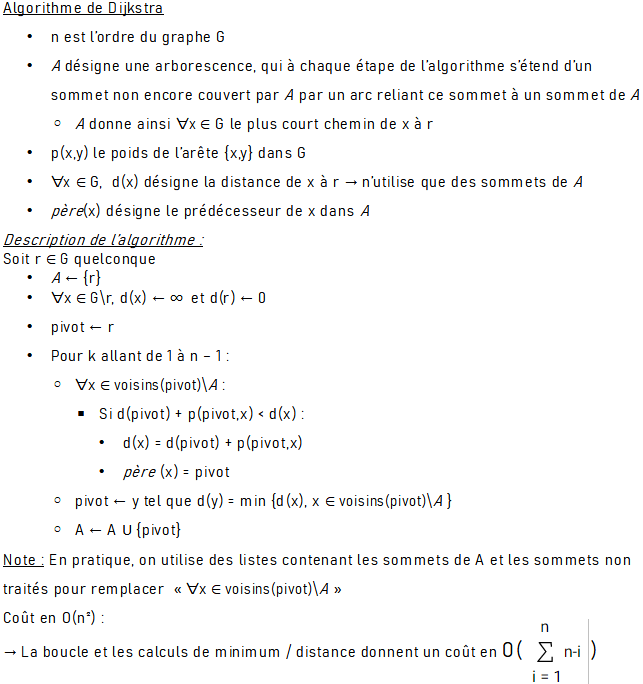

In [5]:
display(Image("images/algo Dijkstra.png", width=600))

In [6]:
def Dijkstra_test(G): #Coût en O(n²), aussi appelé Dijkstra-Moore
    n = np.shape(G)[0]
    D = [np.inf]*n
    D[0] = 0
    pere = dict()
    A_faire = co.deque([0])
    Fait = []
    while (len(A_faire) != 0):
        pivot = A_faire.popleft()
        Fait.append(pivot)
        for v in voisins(pivot,G):
            if v not in Fait :
                d = D[pivot] + G[pivot,v]
                if d < D[v]:
                    D[v] = d
                    pere[v] = pivot
                if v not in A_faire :
                    A_faire.append(v)
    return(D[-1]) #return(D[-1],chemin(pere))

___

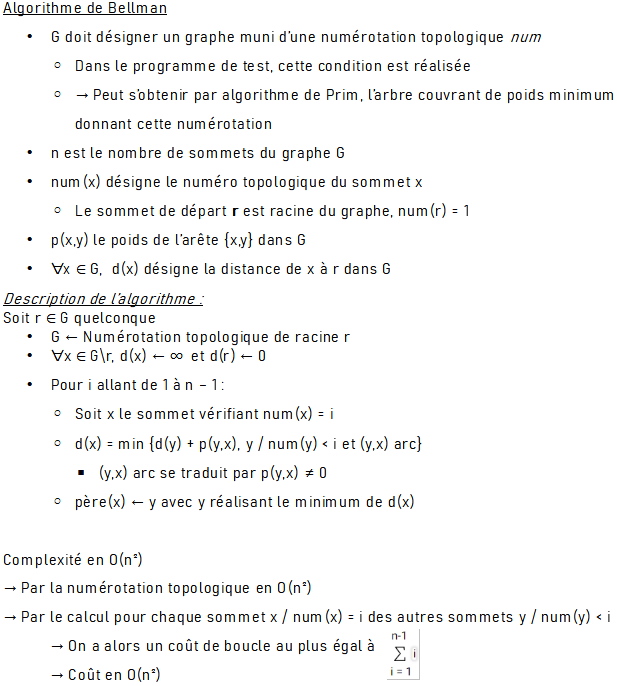

In [7]:
display(Image("images/algo Bellman.png", width=600))

In [8]:
def Bellman(G): #/!\ Nécessite une numérotation topologique num à chaque application, condition réalisée ici, coût en O(n²)
    n = np.shape(G)[0]
    D = [np.inf]*n
    D[0] = 0
    pere = dict()
    for i in range(1,n):
        dist = np.inf
        sommet = 0
        for v in antecedents(i,G):
            d = D[v] + G[v,i]
            if d < dist :
                dist = d
                sommet = v
        D[i] = dist
        pere[i] = sommet
    return(D[-1]) #return(D[-1],chemin(pere))

___

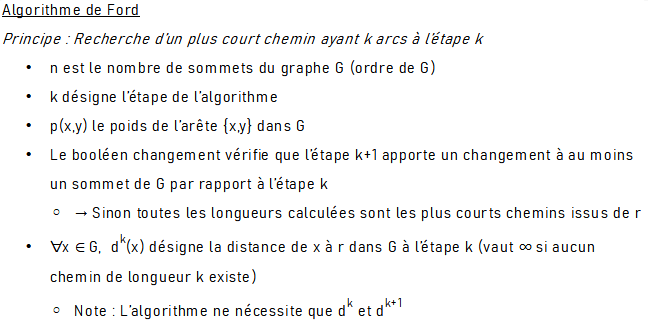

In [9]:
display(Image("images/Ford 1.png", width=600))

In [10]:
def Ford(G): #Coût en O(n².m) avec m le nombre d'arcs du graphe -> Le coût sera généralement supérieur à Dijkstra
    k=0
    n = np.shape(G)[0]
    pere = [np.inf]*n
    D = [pere.copy(),pere.copy()]
    D[0][0] = 0
    pere = dict()
    changement = True
    while k < n and changement == True:
        changement = False
        k+=1
        for i in range(n):
            dist = np.inf
            sommet = 0
            for v in antecedents(i,G):
                d = D[0][v] + G[v,i]
                if d < dist :
                    dist = d
                    sommet = v
            D[1][i] = min(D[0][i], dist)
            if D[1][i] != D[0][i]:
                changement = True
                pere[i] = sommet
        D[0] = D[1].copy()
    return(D[1][-1]) # return(D[1][-1], chemin(pere))

___

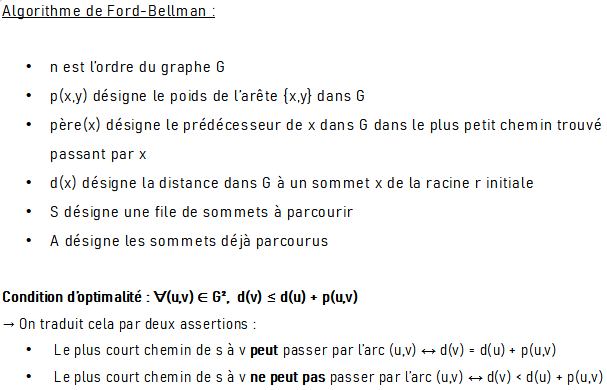

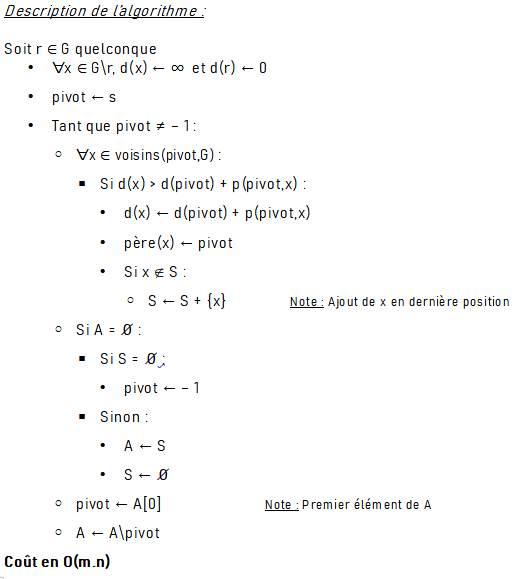

In [11]:
display(Image("images/Ford_Bellman 1.png", width=600))
display(Image("images/Ford_Bellman 2.png", width=600))

In [12]:
def Ford_Bellman(G):
    n = np.shape(G)[0]
    D = [np.inf]*n
    D[0] = 0
    pere = dict()
    pivot = 0
    A = co.deque([]) #File des sommets déjà parcourus
    S = co.deque([pivot]) #File des sommets à parcourir
    while pivot != -1 :
        for v in voisins(pivot,G):
            d = D[pivot] + G[pivot,v]
            if D[v] > d:
                D[v] = d
                pere[v] = pivot
                if v not in S:
                    S.append(v)
        if len(A) == 0:
            if len(S) == 0:
                pivot = -1
            else :
                A = S.copy()
                S = co.deque([])
                pivot = A.popleft()
        else :
            pivot = A.popleft()
    return(D[-1])

___

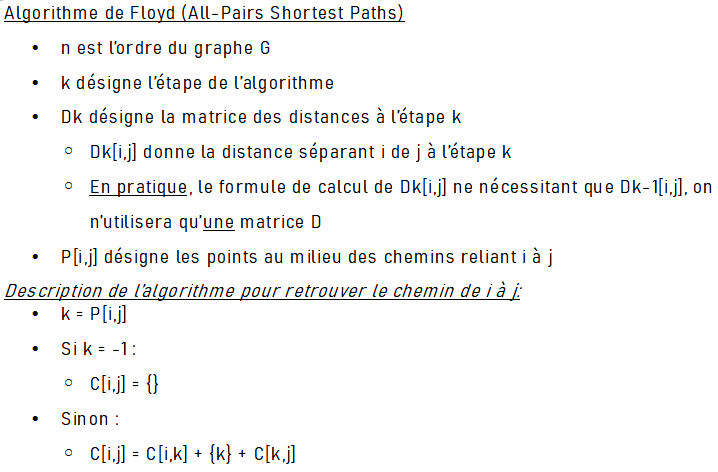

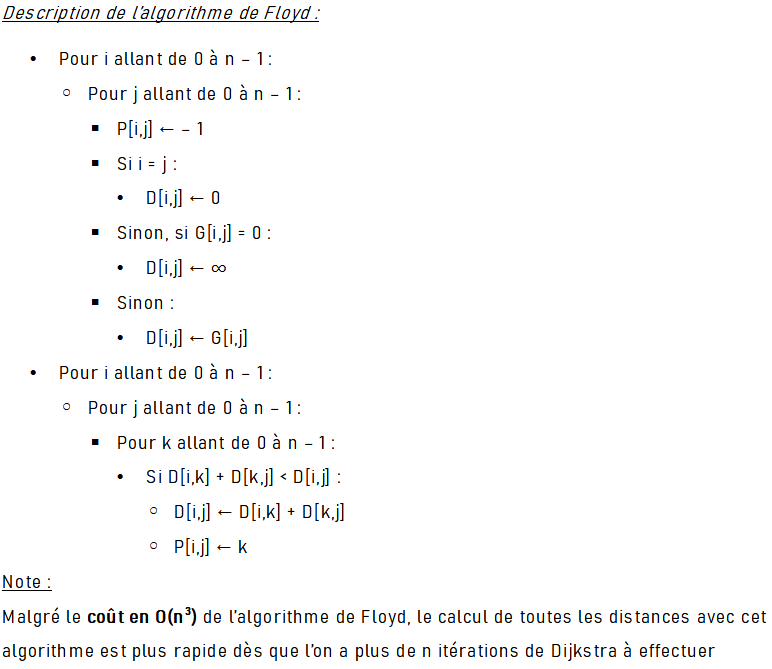

In [13]:
display(Image("images/Floyd 1.png", width=600))
display(Image("images/Floyd 2.png", width=600))

In [14]:
def Floyd(G,a,b):
    n = np.shape(G)[0]
    D = np.zeros((n,n))
    P = np.zeros((n,n))
    for i in range(n):
        for j in range (n):
            P[i,j] = -1
            if i != j:
                if G[i,j] == 0:
                    D[i,j] = np.inf
                else :
                    D[i,j] = G[i,j]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                if D[i,k] + D[k,j] < D[i,j]:
                    D[i,j] = D[i,k] + D[k,j]
                    P[i,j] = k
    return(D[a,b]) #return(D[a,b], chemin_Floyd(a,b,P))

def chemin_Floyd(a,b,P):
    k = int(P[a,b])
    if k == -1:
        return([])
    else :
        return(chemin_Floyd(a,k,P)+[k]+chemin_Floyd(k,b,P))

___

#### Schéma des graphes aléatoires créés pour tester les algorithmes de parcours de graphe

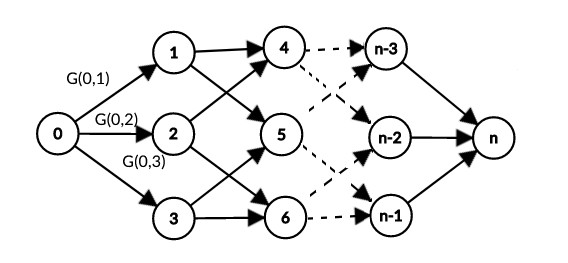

In [15]:
display(Image("images/Graphe.png", width=600))

On teste tous les algorithmes de parcours de graphe pour trouver le plus efficace, et vérifier le coût des algorithmes.

In [16]:
def creer_graphe(n):
    n = 3*(n//3 + 1) + 2
    A = np.eye(n)
    L = [[1,2],[1,3],[2,3]]
    A[0,0] = 1
    A[0,1] = rd.randint(1,10)
    A[0,2] = rd.randint(1,10)
    A[0,3] = rd.randint(1,10)
    for i in range (n//3 - 1):
        for j in range(3):
            for k in L[j]:
                A[3*i+j+1,3*(i+1) + k] = rd.randint(1,10)
    A[n-4,n-1] = rd.randint(1,10)
    A[n-3,n-1] = rd.randint(1,10)
    A[n-2,n-1] = rd.randint(1,10)
    return(A)

def test():
    N = [10,50,100,200,500,1000]
    Di = []
    Be = []
    FoBe = []
    Fl = []
    Fo = []
    for n in N:
        V = []
        A = creer_graphe(n)
        t1 = time.time()
        V.append(Dijkstra_test(A))
        Di.append(time.time() - t1)
        t1 = time.time()
        V.append(Bellman(A))
        Be.append(time.time() - t1)
        t1 = time.time()
        V.append(Ford_Bellman(A))
        FoBe.append(time.time() - t1)
        t1 = time.time()
        V.append(Floyd(A,0,np.shape(A)[0] - 1))
        Fl.append(time.time() - t1)
        t1 = time.time()
        V.append(Ford(A))
        Fo.append(time.time() - t1)
        print(V) #Vérification que les algorithmes retournent tous la même valeur
    return(N,Di,Be,FoBe,Fl,Fo)

In [17]:
if lecteur:
    pass
else:
    N, X, Y, Z, T, Q = test()

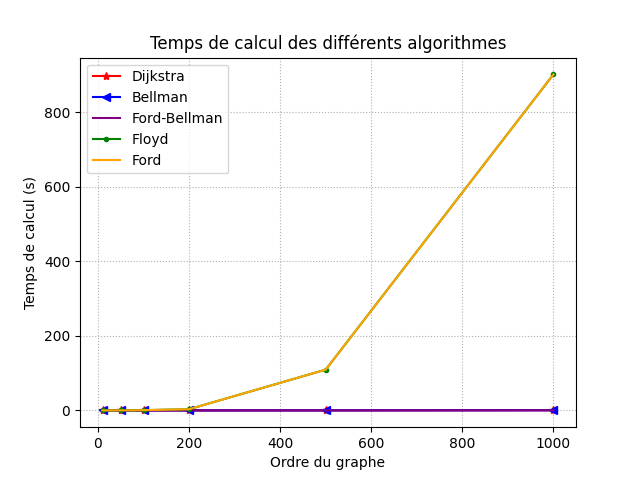

In [18]:
if lecteur:
    display(Image("images/Temps de calcul 1.png", width=600))
else :
    plt.plot(N,X, label='Dijkstra', color = 'red',marker="*")
    plt.plot(N,Y, label='Bellman', color = 'blue', marker ='<')
    plt.plot(N,Z, label='Ford-Bellman', color = 'purple', marker=",")
    plt.plot(N,T, label='Floyd', color = 'green', marker=".")
    plt.plot(N,T, label='Ford', color = 'orange')
    plt.title("Temps de calcul des différents algorithmes")
    plt.xlabel("Ordre du graphe")
    plt.ylabel("Temps de calcul (s)")
    plt.grid(linestyle=':')
    plt.legend()
    #plt.savefig("images/Temps de calcul 1.png")
    plt.show()


Les algorithmes de Floyd et Ford sont les plus coûteux, de l'ordre de $O(n^3)$, étant donné que $m = O(n)$

On compare uniquement les autres algorithmes moins coûteux :

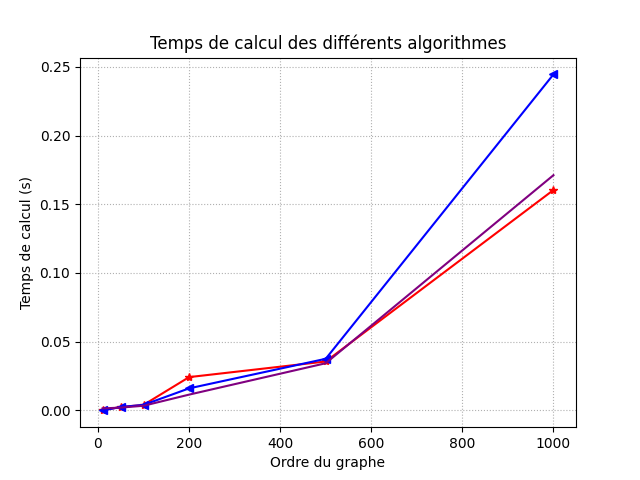

In [19]:
if lecteur:
    display(Image("images/Temps de calcul 2.png", width=600))
else :
    plt.plot(N,X, label='Dijkstra', color = 'red',marker="*")
    plt.plot(N,Y, label='Bellman', color = 'blue', marker ='<')
    plt.plot(N,Z, label='Ford-Bellman', color = 'purple', marker=",")
    plt.title("Temps de calcul des différents algorithmes")
    plt.xlabel("Ordre du graphe")
    plt.ylabel("Temps de calcul (s)")
    plt.grid(linestyle=':')
    #plt.savefig("images/Temps de calcul 2.png")
    plt.legend()

Etant donné que les temps d'exécution sont similaires pour les 3 algorithmes, j'ai décidé de ne conserver que l'algorithme de Dijkstra.

In [20]:
def chemin_Dijkstra(dico, debut, fin):
    L = []
    pivot = fin
    while pivot != debut:
        L.append(pivot)
        pivot = dico[pivot]
    L.append(debut)
    L.reverse()
    return(L)

def Dijkstra(G,a,b):
    Distance = [np.inf]*np.shape(G)[0]
    Distance[a] = 0
    Fait = []
    Trajet = co.deque([])
    Parent = [""]*np.shape(G)[0]
    A_faire = co.deque([a])
    while len(A_faire) != 0:
        pivot = A_faire.popleft()
        Fait.append(pivot)
        voisins_pivot = voisins(pivot,G)
        L = []
        for elem in voisins_pivot:
            L.append([elem,G[pivot,elem]])
            voisins_sommet = L
        for elem in voisins_sommet:
            if elem[0] not in Fait:
                if Distance[elem[0]] > (Distance[pivot] + elem[1]):
                    Distance[elem[0]] = Distance[pivot] + elem[1]
                    Parent[elem[0]] = pivot
                if elem[0] not in A_faire:
                    A_faire.append(elem[0])
    Trajet.appendleft(b)
    while (Trajet[0] != a):
        Trajet.appendleft(Parent[Trajet[0]])
    return(Trajet)

___

### Constantes / Listes globales

In [21]:
global ALL_stations_name
ALL_stations_name = []
global ALL_stations
ALL_stations = []
global ALL_lignes
ALL_lignes = []
global ALL_lignes_name
ALL_lignes_name = []
global TEMPS # Désigne l'évolution des tick de 30 secondes
TEMPS = [0] # Initialisé à 0, finit à 2880 pour une journée, ou moins si l'on considère des transports 5h00 du matin jusqu'à 00h00
global TOT_VOY
TOT_VOY = [0]

if lecteur: # Les consultants du code ne doivent pas recréer le fichier
    pass
else:
    fichier = open("Résultats.txt",'w')
    fichier.close()

## Désigne l'attribution de station à la création d'un voyageur

global popularite_stations
popularite_stations = []

##Permet de sauver de l'espace mémoire, on ne peut supprimer des objets, alors on les réattribue

global Trains_disponibles
Trains_disponibles = []
global Trains_en_circulation
Trains_en_circulation = []
global ALL_terminus
ALL_terminus = []
global Voyageurs_disponibles
Voyageurs_disponibles = []

___

### Classes

In [22]:
## Les files sont triées dans le même ordre que les voisins de chaque station (station.voisins[1] = station.files[1].direction) par exemple
class File:
    def __init__(self,station1,station2): #File d'attente pour aller de la station 1 à la station 2
        self.file = co.deque([])
        self.station = station1
        self.direction = station2
        #self.station = ALL_stations[ALL_stations_name.index(station1)]
        #self.direction = ALL_stations[ALL_stations_name.index(station2)]

    def add(self,elem): #Ajout d'un nouvel élément à droite, on retire l'élément à gauche pour l'ajouter au train -> FIFO
        self.file.append(elem)


class Train :
    def __init__(self,ligne,sens = 1): #Sens = -1 pour l'autre direction
        self.ligne = ligne
        self.stations_a_parcourir = co.deque(ALL_lignes[ALL_lignes_name.index(ligne)].stations)
        if sens == -1:
            self.stations_a_parcourir.reverse()
        self.capacite = ALL_lignes[ALL_lignes_name.index(ligne)].capacite_trains
        self.passagers = []
        self.attente = 0
        Trains_en_circulation.append(self)

    def reattribution_train(self,ligne,sens = 1):
        self.ligne = ligne
        self.stations_a_parcourir = co.deque(ALL_lignes[ALL_lignes_name.index(self.ligne)].stations)
        if sens == -1:
            self.stations_a_parcourir.reverse()
        self.capacite = ALL_lignes[ALL_lignes_name.index(ligne)].capacite_trains
        self.passagers = []
        self.attente = 0
        Trains_en_circulation.append(self)

    def depart_train(self):
        self.descente_passager(self.stations_a_parcourir[0],self.stations_a_parcourir[1])
        self.montee_passager(self.stations_a_parcourir[0],self.stations_a_parcourir[1])
        self.stations_a_parcourir.popleft()
        self.attente = ALL_lignes[ALL_lignes_name.index(self.ligne)].temps_moyen

    def deplacement(self):
        if self.attente != 0 : #Dernier tick avant l'arrivée
            self.attente -=1
        elif len(self.stations_a_parcourir) == 1 : #Plus que la dernière station, soit le terminus
            self.descente_passager(self.stations_a_parcourir[0])
            Trains_disponibles.append(Trains_en_circulation.pop(Trains_en_circulation.index(self)))
        else :
            self.depart_train()

    def descente_passager(self,station,direction = 0):
        L = self.passagers.copy() #La copie de la liste permet de palier à la modification dynamique de la liste
        for voyageur in L: #Actualisation des gares restantes des passagers une fois arrivée à la gare suivante
            voyageur.trajet.popleft()
            if len(voyageur.trajet) == 1: #Il ne reste plus que la station où se situe le train, il est arrivé
                voyageur.bon_port()
                self.passagers.pop(self.passagers.index(voyageur))
            elif direction == 0: #Le train est au terminus
                self.passagers.pop(self.passagers.index(voyageur))
                voyageur.placement_station()
            elif voyageur.trajet[1] != ALL_stations[ALL_stations_name.index(direction)]: #Il doit sortir du train
                self.passagers.pop(self.passagers.index(voyageur))
                voyageur.placement_station() #Sinon il reste dedans, il ne se passe rien

    def montee_passager(self,station,direction):
        Places_disponibles = self.capacite - len(self.passagers)
        station = ALL_stations[ALL_stations_name.index(station)]
        direction = ALL_stations[ALL_stations_name.index(direction)]
        file_concernee = station.files[station.voisins.index(direction.nom)]
        while (Places_disponibles > 0) and (len(file_concernee.file) != 0):
            Places_disponibles -= 1
            self.passagers.append(file_concernee.file.popleft()) #Principe de la file d'attente FIFO

class Station:
    def __init__(self, nom, lignes, popularite, coordonnees, terminus = [False,""]):
        self.nom = nom
        self.lignes = lignes
        self.popularite = popularite
        self.coordonnees = coordonnees
        self.frequentation = 0
        self.terminus = terminus
        ALL_stations_name.append(nom)
        for i in range (self.popularite):
            popularite_stations.append(self.nom)
        self.voisins = []
        self.files = []

    def fin_init(self): # NOTE : doit attendre la fin de création de toutes les stations et lignes pour fonctionner, d'où le nom fin_init
        Rep=[]
        for elem in self.lignes:
            Rep.append(ALL_lignes_name[ALL_lignes_name.index(elem)])
        self.lignes = Rep
        Rep = [] ### Création des voisins
        for ligne in self.lignes:
            num_station = ALL_lignes[ALL_lignes_name.index(ligne)].stations.index(self.nom)
            if num_station == 0:
                Rep.append(ALL_lignes[ALL_lignes_name.index(ligne)].stations[1])
            elif num_station == (len(ALL_lignes[ALL_lignes_name.index(ligne)].stations) - 1):
                Rep.append(ALL_lignes[ALL_lignes_name.index(ligne)].stations[num_station-1])
            else :
                Rep.append(ALL_lignes[ALL_lignes_name.index(ligne)].stations[num_station + 1])
                Rep.append(ALL_lignes[ALL_lignes_name.index(ligne)].stations[num_station - 1])
        self.voisins = Rep
        for voisin_station in self.voisins: ### Création des files
            file = File(self.nom,voisin_station)
            self.files.append(file)

class Ligne:
    def __init__(self,nom,stations,connexions,capacite_trains,couleur,temps_moyen,depart_frequence):
        self.nom = nom
        self.stations = stations
        self.terminus = [stations[0],stations[-1]]
        self.connexions = connexions
        self.capacite_trains = capacite_trains
        self.couleur = couleur
        self.temps_moyen = temps_moyen #Temps moyen de parcours entre deux stations (en ticks) -> Est une première modélisation
        ALL_lignes_name.append(nom)
        self.depart_frequence = depart_frequence
        self.attente = 0

class Voyageur:
    def __init__(self,chemin,nomvoy=""): # t = TEMPS permet de récupérer la date d'un tick au départ, et celui à l'arrivée
        self.nom = nomvoy
        self.trajet = chemin
        self.depart = self.trajet[0] #Renvoie le nombre associé à la station
        self.arrivee = self.trajet[-1]
        self.temps_depart = TEMPS[0]
        ALL_stations[self.trajet[0]].files[ALL_stations[self.trajet[0]].voisins.index(ALL_stations_name[self.trajet[1]])].add(self) #Placement du voyageur dans la station de départ

    def placement_station(self): #Placement du voyageur dans la file d'attente correspondante
        ALL_stations[self.trajet[0]].files[ALL_stations[self.trajet[0]].voisins.index(ALL_stations_name[self.trajet[1]])].add(self)

    def reattribution(self):
        self.trajet = genere_trajet()
        self.depart = self.trajet[0]
        self.arrivee = self.trajet[-1]
        self.temps_depart = TEMPS[0]
        self.placement_station()

    def duree(self):
        return(TEMPS[0] - self.temps_depart)

    def bon_port(self):
        fichier = open("Résultats.txt",'a')
        fichier.write("Depart : " + ALL_stations_name[self.depart] + " ; Arrivee : " + ALL_stations_name[self.arrivee] + " ; Duree : " + str(self.duree()) + " ;\n")
        fichier.close()
        Voyageurs_disponibles.append(self)

___
### Modélisation du métro de Montréal

- Ligne 1 : Verte
- Ligne 2 : Orange
- Ligne 4 : Jaune
- Ligne 5 : Bleue

Ligne orange et verte : 2400 places
Lignes bleues, vertes : 1600 places

#### Répartition des indices de popularité :

Popularité de 15 maximale, Intersection centrale 10, Centre fréquenté 8, Centre 5, Intersection Autour 7, Autour proche 3, Reste 1 (Georges Vanier)

In [23]:
## Ligne 1 - verte

Angrignon = Station("Angrignon",["Ligne 1"],1,[592,14],[True,1])
Monk = Station("Monk",["Ligne 1"],3,[565,32])
Jolicoeur = Station("Jolicoeur",["Ligne 1"],3,[531,46])
Verdun = Station("Verdun",["Ligne 1"],3,[498,38])
De_L_Eglise = Station("De L'Église",["Ligne 1"],5,[470,52])
LaSalle = Station("LaSalle",["Ligne 1"],5,[446,66])
Charlevoix = Station("Charlevoix",["Ligne 1"],8,[450,96])
Lionel_Groulx = Station("Lionel-Groulx",["Ligne 1","Ligne 2"],10,[472,121])
Atwater = Station("Atwater",["Ligne 1"],8,[480,170])
Guy	 = Station("Guy-Concordia (Guy)",["Ligne 1"],12,[446,189])
Peel = Station("Peel",["Ligne 1"],8,[413,209])
McGill = Station("McGill",["Ligne 1"],13,[379,229])
Place_Des_Arts = Station("Place-des-Arts",["Ligne 1"],8,[345,247])
Saint_Laurent = Station("Saint-Laurent",["Ligne 1"],8,[313,266])
Berri_UQAM = Station("Berri-UQAM",["Ligne 1","Ligne 2","Ligne 4"],15,[286,282],[True,4])
Beaudry = Station("Beaudry",["Ligne 1"],8,[247,303])
Papineau = Station("Papineau",["Ligne 1"],5,[222,319])
Frontenac = Station("Frontenac",["Ligne 1"],5,[228,342])
Prefontaine = Station("Préfontaine",["Ligne 1"],3,[217,361])
Joliette = Station("Joliette",["Ligne 1"],3,[191,375])
Pie_IX = Station("Pie-IX",["Ligne 1"],3,[168,388])
Viau = Station("Viau",["Ligne 1"],1,[144,400])
Assomption = Station("Assomption",["Ligne 1"],1,[149,425])
Cadillac = Station("Cadillac",["Ligne 1"],1,[140,447])
Langelier = Station("Langelier",["Ligne 1"],1,[115,464])
Radisson = Station("Radisson",["Ligne 1"],1,[92,476])
Honore_Beaugrand = Station("Honoré-Beaugrand",["Ligne 1"],1,[67,491],[True,1])

## Ligne 2 - orange

Montmorency = Station("Montmorency",["Ligne 2"],1,[730,570],[True,2])
De_La_Concorde = Station("De La Concorde",["Ligne 2"],1,[650,570])
Cartier = Station("Cartier",["Ligne 2"],1,[564,557])
Henri_Bourassa = Station("Henri-Bourassa",["Ligne 2"],1,[512,510])
Sauve = Station("Sauvé",["Ligne 2"],3,[492,487])
Cremazie = Station("Crémazie",["Ligne 2"],3,[470,466])
Jarry = Station("Jarry",["Ligne 2"],3,[450,445])
#Jean_Talon = Station("Jean-Talon",["Ligne 2","Ligne 5"],1,[730,570])                 voir ligne 5
Beaubien = Station("Beaubien",["Ligne 2"],5,[402,397])
Rosemont = Station("Rosemont",["Ligne 2"],5,[380,376])
Laurier = Station("Laurier",["Ligne 2"],5,[360,357])
Mont_Royal = Station("Mont-Royal",["Ligne 2"],8,[340,336])
Sherbrooke = Station("Sherbrooke",["Ligne 2"],8,[319,315])
#Berri_UQAM = Station("Berri-UQAM",["Ligne 1","Ligne 2","Ligne 4"],1,[730,570])                   voir ligne 1
Champ_De_Mars = Station("Champ-de-Mars",["Ligne 2"],8,[273,239])
Place_D_Armes = Station("Place-d'Armes",["Ligne 2"],8,[308,220])
Square_Victoria_OACI = Station("Square-Victoria-OACI",["Ligne 2"],8,[342,200])
Bonaventure = Station("Bonaventure",["Ligne 2"],12,[376,181])
Lucien_L_Allier = Station("Lucien-L'Allier",["Ligne 2"],8,[412,160])
Georges_Vanier = Station("Georges-Vanier",["Ligne 2"],8,[445,140])
#Lionel_Groulx = Station("Lionel-Groulx",["Ligne 1","Ligne 2"],1,[730,570])               voir ligne 1
Place_Saint_Henri = Station("Place-Saint-Henri",["Ligne 2"],7,[522,137])
Vendome = Station("Vendôme",["Ligne 2"],7,[550,166])
Villa_Maria = Station("Villa-Maria",["Ligne 2"],5,[573,188])
#Snowdon = Station("Snowdon",["Ligne 2","Ligne 5"],8,[730,570],True)                                   voir ligne 5
Cote_Sainte_Catherine = Station("Côte-Sainte-Catherine",["Ligne 2"],3,[620,234])
Plamondon = Station("Plamondon",["Ligne 2"],1,[638,254])
Namur = Station("Namur",["Ligne 2"],1,[658,274])
De_La_Savane = Station("De La Savane",["Ligne 2"],1,[678,294])
Du_College = Station("Du Collège",["Ligne 2"],3,[698,314])
Cote_Vertu = Station("Côté Vertu",["Ligne 2"],10,[730,346],[True,2])

## Ligne 4 - jaune

#Berri_UQAM = Station("Berri-UQAM",["Ligne 1","Ligne 2","Ligne 4"],1,[197,256],[True,4])      voir ligne 1
Jean_Drapeau = Station("Jean-Drapeau",["Ligne 4"],8,[197,256])
Longueuil = Station("Longueuil Université-de-Sherbrooke",["Ligne 4"],8,[134,277],[True,4])

## Ligne 5 - bleue

Snowdon = Station("Snowdon",["Ligne 2","Ligne 5"],8,[601,218],[True,5])
Cote_Des_Neiges = Station("Côte-des-Neiges",["Ligne 5"],5,[556,244])
Universite_De_Montreal = Station("Université-de-Montréal",["Ligne 5"],3,[515,268])
Edouard_Montpetit = Station("Édouard-Montpetit",["Ligne 5"],3,[474,291])
Outremont = Station("Outremont",["Ligne 5"],3,[482,322])
Acadie = Station("Acadie",["Ligne 5"],3,[490,355])
Parc = Station("Parc",["Ligne 5"],8,[494,385])
De_Castelnau = Station("De Castelnau",["Ligne 5"],3,[457,403])
Jean_Talon = Station("Jean-Talon",["Ligne 2","Ligne 5"],8,[425,420])
Fabre = Station("Fabre",["Ligne 5"],3,[390,438])
D_Iberville = Station("D'Iberville",["Ligne 5"],3,[360,456])
Saint_Michel = Station("Saint-Michel",["Ligne 5"],1,[334,470],[True,5])

ALL_stations = [Angrignon,Monk,Jolicoeur,Verdun,De_L_Eglise,LaSalle,Charlevoix,Lionel_Groulx,Atwater,Guy,Peel,McGill,Place_Des_Arts,Saint_Laurent,Berri_UQAM,Beaudry,Papineau,Frontenac,Prefontaine,Joliette,Pie_IX,Viau,Assomption,Cadillac,Langelier,Radisson,Honore_Beaugrand,Montmorency,De_La_Concorde,Cartier,Henri_Bourassa,Sauve,Cremazie,Jarry,Beaubien,Rosemont,Laurier,Mont_Royal,Sherbrooke,Champ_De_Mars,Place_D_Armes,Square_Victoria_OACI,Bonaventure,Lucien_L_Allier,Georges_Vanier,Place_Saint_Henri,Vendome,Villa_Maria,Cote_Sainte_Catherine,Plamondon,Namur,De_La_Savane,Du_College,Cote_Vertu,Jean_Drapeau,Longueuil,Snowdon,Cote_Des_Neiges,Universite_De_Montreal,Edouard_Montpetit,Outremont,Acadie,Parc,De_Castelnau,Jean_Talon,Fabre,D_Iberville,Saint_Michel]

Ligne_1 = Ligne("Ligne 1",['Angrignon','Monk','Jolicoeur','Verdun',"De L'Église",'LaSalle','Charlevoix','Lionel-Groulx','Atwater','Guy-Concordia (Guy)','Peel','McGill','Place-des-Arts','Saint-Laurent','Berri-UQAM','Beaudry','Papineau','Frontenac','Préfontaine','Joliette','Pie-IX','Viau','Assomption','Cadillac','Langelier','Radisson','Honoré-Beaugrand'],[2,4],1600,'green',3,18)

Ligne_2 = Ligne("Ligne 2",['Montmorency','De La Concorde','Cartier','Henri-Bourassa','Sauvé','Crémazie','Jarry','Jean-Talon','Beaubien','Rosemont','Laurier','Mont-Royal','Sherbrooke','Berri-UQAM','Champ-de-Mars',"Place-d'Armes",'Square-Victoria-OACI','Bonaventure',"Lucien-L'Allier",'Georges-Vanier','Lionel-Groulx','Place-Saint-Henri','Vendôme','Villa-Maria','Snowdon','Côte-Sainte-Catherine','Plamondon','Namur','De La Savane','Du Collège','Côté Vertu'],[1,4,5],2400,'orange',3,18)

Ligne_4 = Ligne("Ligne 4",['Berri-UQAM','Jean-Drapeau','Longueuil Université-de-Sherbrooke'],[1,2],2400,'yellow',4,15)

Ligne_5 = Ligne("Ligne 5",['Snowdon','Côte-des-Neiges','Université-de-Montréal','Édouard-Montpetit','Outremont','Acadie','Parc','De Castelnau','Jean-Talon','Fabre',"D'Iberville",'Saint-Michel'],[1],1600,'blue',3,19)

ALL_lignes=[Ligne_1,Ligne_2,Ligne_4,Ligne_5]

In [24]:
## Création de la matrice graphe

def creer_liaison():
    N = len(ALL_stations)
    M = np.zeros((N,N)) #Création de la matrice 'graphe'
    for i in range (N): #Station de départ
        for j in range (N): #Station d'arrivée
            depart = ALL_stations[i]
            arrivee = ALL_stations[j]
            if depart.nom in arrivee.voisins:
                M[i,j] = temps_ligne_commune(depart,arrivee)
    return(M)

def temps_ligne_commune(depart,arrivee): #Temps de la liaison séparant la station de départ et la station d'arrivée
    for ligne in depart.lignes:
        if ligne in arrivee.lignes:
            return(ALL_lignes[ALL_lignes_name.index(ligne)].temps_moyen)

def trajet_station(L): #Renvoie le trajet avec le nom des stations plutôt qu'avec le numéro des stations
    R = []
    for elem in L:
        R.append(ALL_stations_name[elem])
    return(R)

def actualisation(G):
    M = G.copy()
    n = np.shape(M)[0]

def fin_initialisation():
    for station in ALL_stations:
        station.fin_init()
        if station.terminus[0] == True :
            ALL_terminus.append(station)
    return(creer_liaison())

global Graphe
Graphe = fin_initialisation()

### Limite sur le matériel roulant

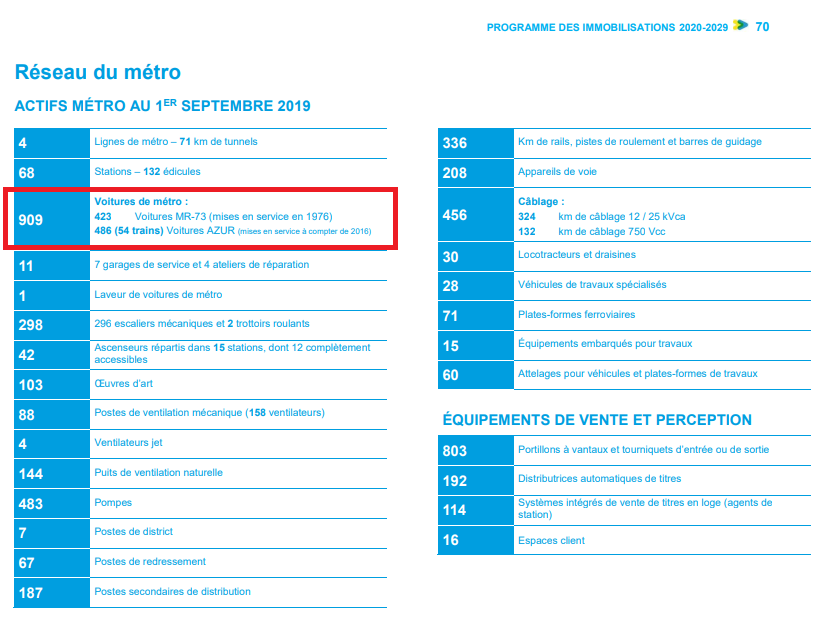

In [25]:
display(Image("images/Nombre de voitures.png", width=600))

In [26]:
def genere_trajet():
    a = 0
    b = 0
    MAX = len(popularite_stations)
    while(a == b):
        a = ALL_stations_name.index(popularite_stations[rd.randint(0,MAX-1)])
        b = ALL_stations_name.index(popularite_stations[rd.randint(0,MAX-1)])
    return(Dijkstra(Graphe,a,b))

## Création de nouveaux voyageurs

def nouveaux_voyageurs(n):
    cpt = 0
    TOT_VOY[0] += n
    while(len(Voyageurs_disponibles)) != 0 and cpt < n:
        Voyageurs_disponibles.pop().reattribution()
        cpt+=1
    for i in range (cpt,n):
        nouveau_voyageur = Voyageur(genere_trajet(),str(TOT_VOY[0]))

## Création de nouveaux trains

def nouveaux_trains():
    if len(Trains_en_circulation) >= 909 : #Limite du matériel roulant
        for ligne in ALL_lignes:
            if ligne.attente != 0:
                ligne.attente -= 1
    for station in ALL_terminus :
        ligne = ALL_lignes[[1,2,4,5].index(station.terminus[1])]
        if ligne.attente == 0: #Il est possible d'attribuer un train
            creer_trains(ligne)
            ligne.attente = ligne.depart_frequence
        else :
            ligne.attente -=1

def creer_trains(ligne):
    nom_ligne = ALL_lignes_name[ALL_lignes.index(ligne)]
    if len(Trains_disponibles) >= 2:
        Trains_disponibles.pop().reattribution_train(nom_ligne,1)
        Trains_disponibles.pop().reattribution_train(nom_ligne,-1)
    elif len(Trains_disponibles) == 1:
        Trains_disponibles.pop().reattribution_train(nom_ligne,1)
        nv_train = Train(nom_ligne,-1)
    else :
        nv_train_1 = Train(nom_ligne,1)
        nv_train_2 = Train(nom_ligne,-1)

## Fonction qui trace le graphe

def init_trace():
    croisement=[]
    for elem in ALL_lignes:
        X,Y = [],[]
        for name in elem.stations :
            station = ALL_stations[ALL_stations_name.index(name)]
            if len(station.lignes)>1:
                croisement.append([-station.coordonnees[0],station.coordonnees[1]])
            X.append(-station.coordonnees[0])
            Y.append(station.coordonnees[1])
        plt.plot(X,Y,label=elem.nom,marker='o',markersize=5,linewidth=2,color=elem.couleur)
    for elem in croisement:
        plt.plot(elem[0],elem[1],marker='o',color='black')
    plt.legend()
    plt.title("Plan du Métro à Montréal")
    ax = plt.gca()
    ax.set_facecolor('#D3D3D3')
    ax.axes.xaxis.set_visible(False)
    ax.axes.yaxis.set_visible(False)

In [27]:
## Programme - Simulation
# Liste des nouveaux passagers par tick (30 secondes) dans une journée

def simulation(L):
    A=[0]
    for n_nouveaux_voyageurs in L:
        TEMPS[0] += 1
        nouveaux_voyageurs(n_nouveaux_voyageurs)
        nouveaux_trains()
        A.append(total_BERRI())
        for train in Trains_en_circulation :
            train.deplacement()
    Condition = True
    while(Condition):
        Condition = False
        nouveaux_trains()
        TEMPS[0] += 1
        for train in Trains_en_circulation :
            train.deplacement()
        A.append(total_BERRI())
        for station in ALL_stations :
            for L in station.files :
                if len(L.file) == 0:
                    Condition = False or Condition
                else :
                    Condition = True
    while(len(Trains_en_circulation) != 0):
        for train in Trains_en_circulation :
            train.deplacement()
        A.append(total_BERRI())
        TEMPS[0]+=1
    return(A)

def simulation2(L):
    for n_nouveaux_voyageurs in L:
        TEMPS[0] += 1
        nouveaux_voyageurs(n_nouveaux_voyageurs)
        nouveaux_trains()
        for train in Trains_en_circulation :
            train.deplacement()

def total_BERRI(): #Passager en attante à la station Berri-UQAM
    TOT = 0
    for element_file in ALL_stations[ALL_stations_name.index("Berri-UQAM")].files :
        TOT += len(element_file.file)
    return(TOT)

def continuer(n):
    nouveaux_voyageurs(n)
    nouveaux_trains()
    for train in Trains_en_circulation :
        train.deplacement()
    TEMPS[0] +=1

def montre_trajet(L): #Liste de station à parcourir
    X = []
    Y = []
    for elem in L:
        C = ALL_stations[ALL_stations_name.index(elem)].coordonnees
        X.append(-C[0])
        Y.append(C[1])
    init_trace()
    plt.plot(X,Y,linewidth=2, marker = '*', linestyle='solid',color = 'red',label='Exemple de trajet')
    plt.legend()
    plt.show()
    
def moyenneur(L,k):
    n = len(L)
    if k>n:
        return L[:]
    L1 = []
    for i in range(k-1):
        L1.append(sum(L[:i+1])/(i+1))
    for i in range(k-1,n):
        L1.append(sum(L[i-k+1:i+1])/k)
    return L1

Exemple de trajet :

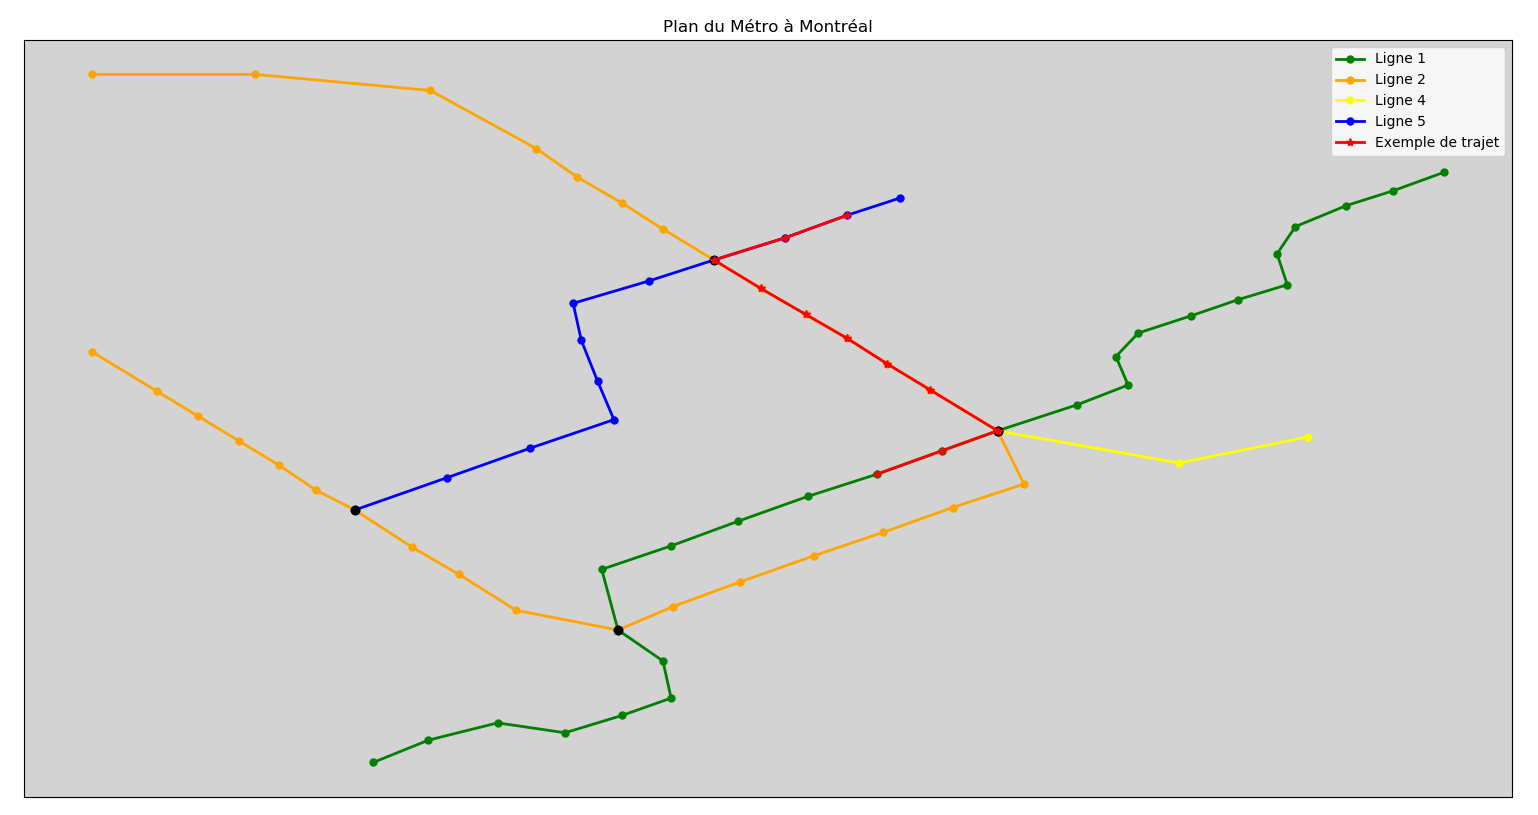

In [28]:
if lecteur:
    display(Image("images/Exemple 1 de trajet.png", width=1200))
else:
    A = genere_trajet()
    B = []
    for elem in A:
        B.append(ALL_stations_name[elem])
    montre_trajet(B)

___

### Explication du fonctionnement de la simulation, hypothèses :

Les trains circulent selon la fréquence de passage moyenne du weekend :

- Ligne verte : 

Temps de circulation entre deux stations : 3 ticks, 1 minute 30

Fréquence de départ depuis le terminus (ou fréquence de passage) 18 ticks, soit 9 minutes

- Ligne orange :

Temps de circulation entre deux stations : 3 ticks, 1 minute 30

Fréquence de départ depuis le terminus (ou fréquence de passage) 18 ticks, soit 9 minutes

- Ligne jaune :

Temps de circulation entre deux stations : 4 ticks, 2 minutes

Fréquence de départ depuis le terminus (ou fréquence de passage) 15 ticks, soit 7 minutes 30 secondes

- Ligne bleue :

Temps de circulation entre deux stations : 3 ticks, 1 minute 30

Fréquence de départ depuis le terminus (ou fréquence de passage) 19 ticks, soit 9 minutes 30 secondes

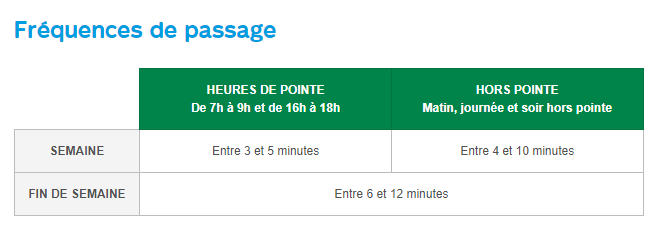

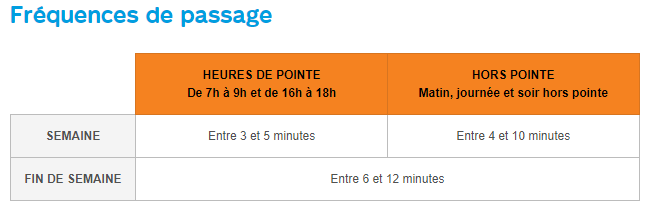

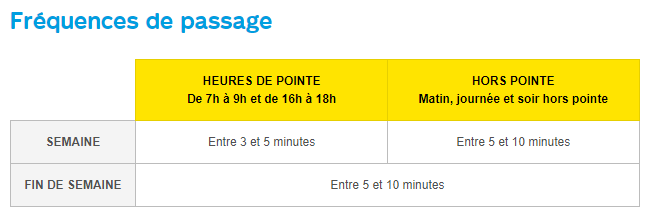

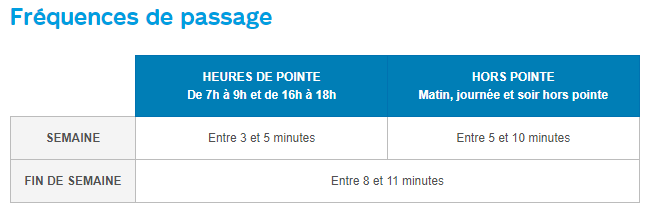

In [29]:
display(Image("images/Frequence de passage ligne verte.png", width=600), Image("images/Frequence de passage ligne orange.png", width=600), Image("images/Frequence de passage ligne jaune.png", width=600), Image("images/Frequence de passage ligne bleue.png", width=600))

### Choix du plus court chemin

Contrairement aux choix annoncés par les applications RAPT, Google Maps ou autre, j'ai décidé de prendre en compte le temps d'attente des passagers à une station dans le temps total à prévoir pour un passager. Donc admettons que je veuille rentrer dans un train déjà plein, avec un nombre de passagers en attente conséquent sur le quai, il est très probable que je ne puisse pas entrer dans le train, il est donc préférable (et plus confortable) de dévier.

Cela est pris en compte dans la pondération dynamique de chaque sommet du graphe, en fonction de la direction. Cela peut se voir sur l'exemple suivant :



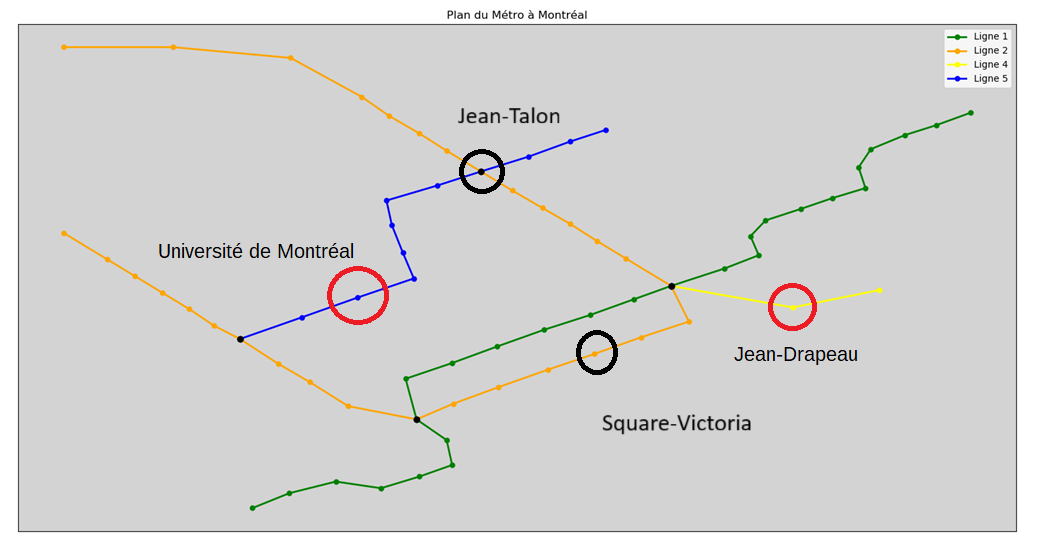

In [30]:
display(Image("images/Exemple 2 explication.png", width=1200))

Entre les stations Université de Montréal et Jean-Drapeau, il est possible de prendre plusieurs itinéraires différents :

- A priori le plus rapide, en passant par la station Jean-Talon, en prenant la ligne 5 vers le Nord, puis la ligne 2 et enfin la ligne 4.
- Si jamais la station Jean-Talon est trop bondée, et que le temps d'attente prévu à la station dépasse l'alternative :
    - Passage par la ligne 5 vers le Sud, puis ligne 2 par la station Square-Victoria, pour ensuite prendre la ligne 4.
    - Enfin, si jamais Square-Victoria subit aussi ce problème d'affluence, alors le trajet est dévié par la ligne 1.

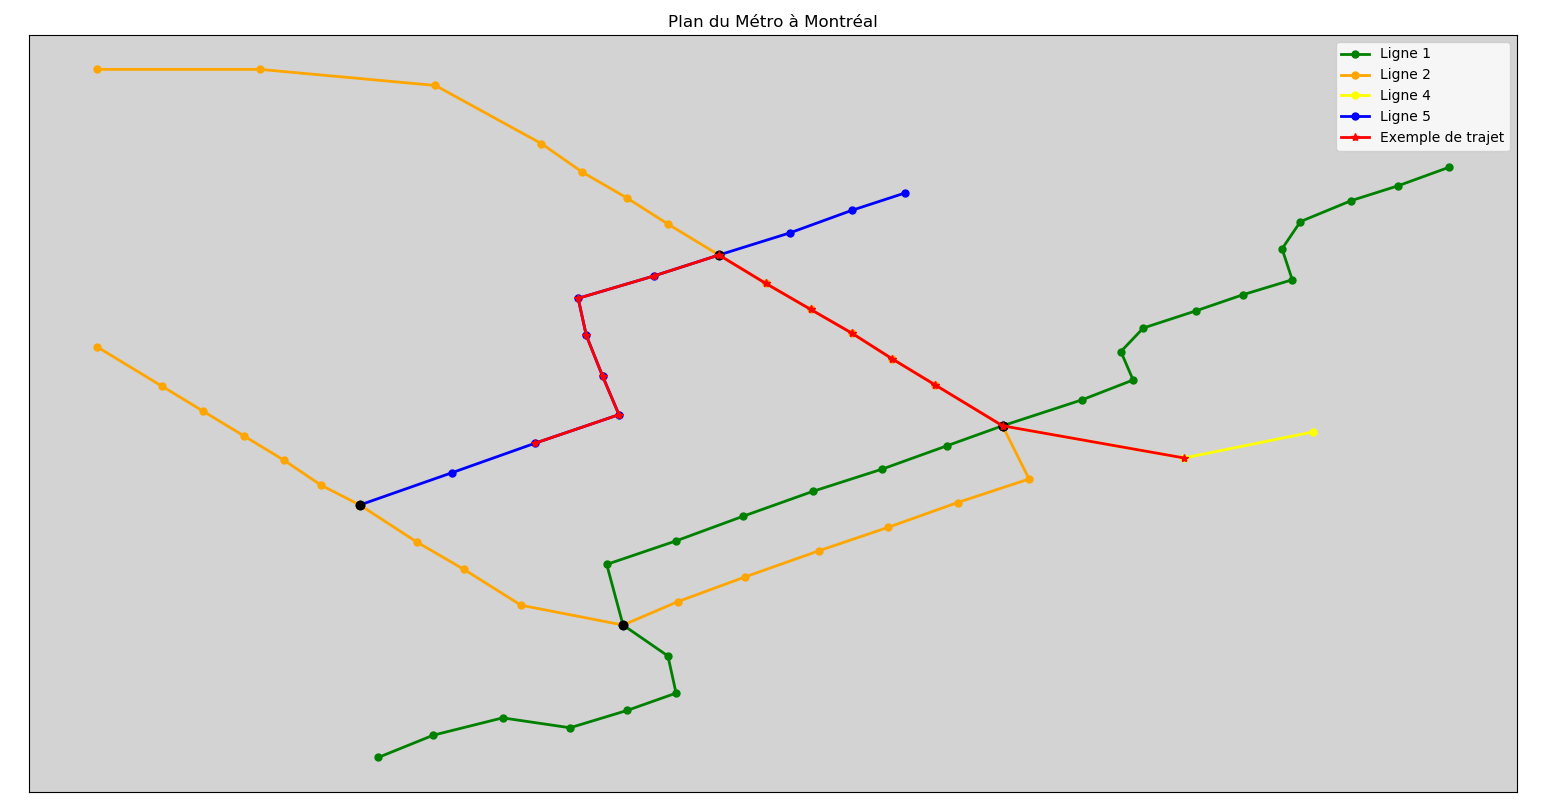

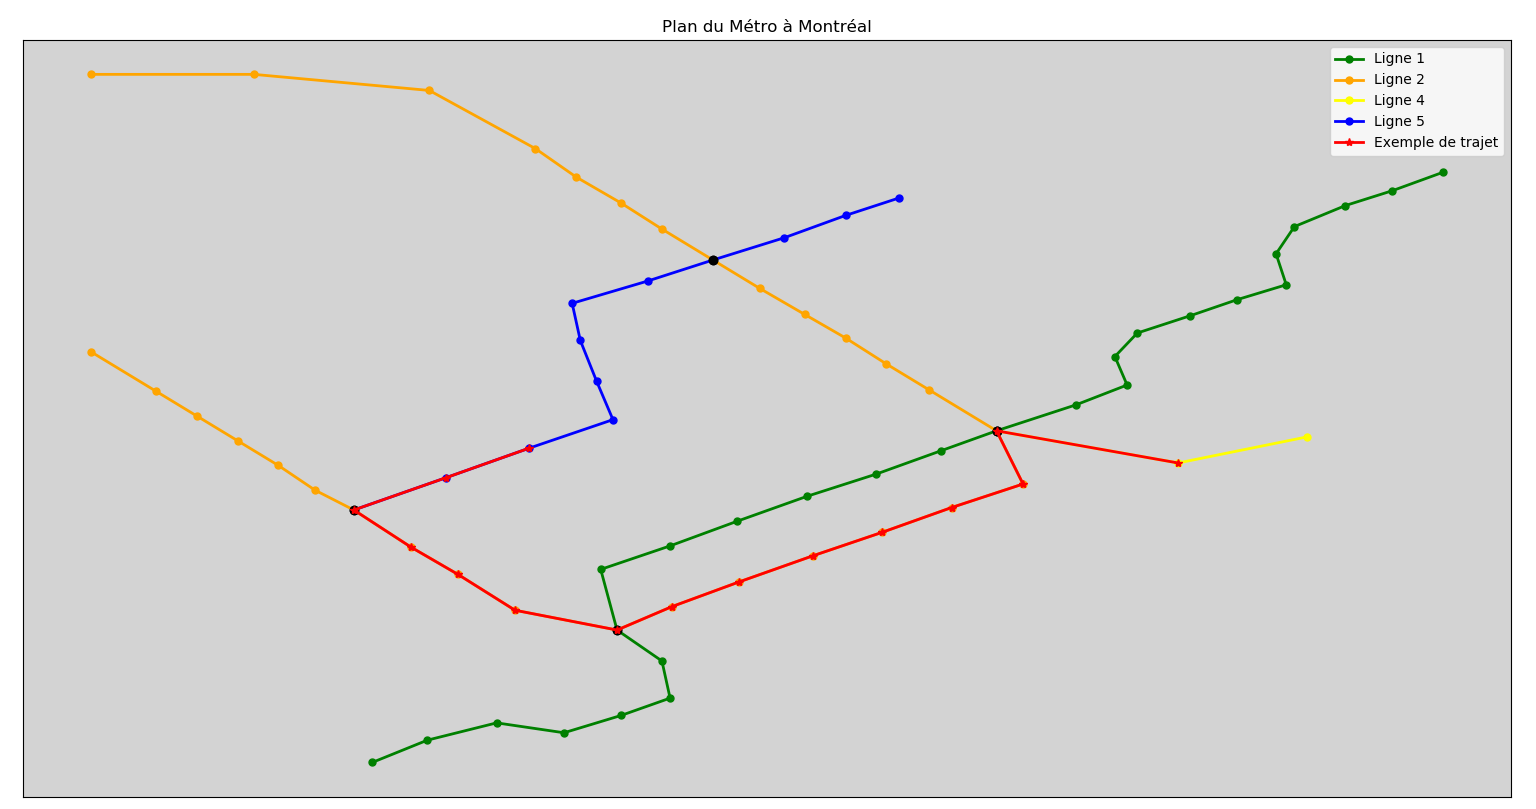

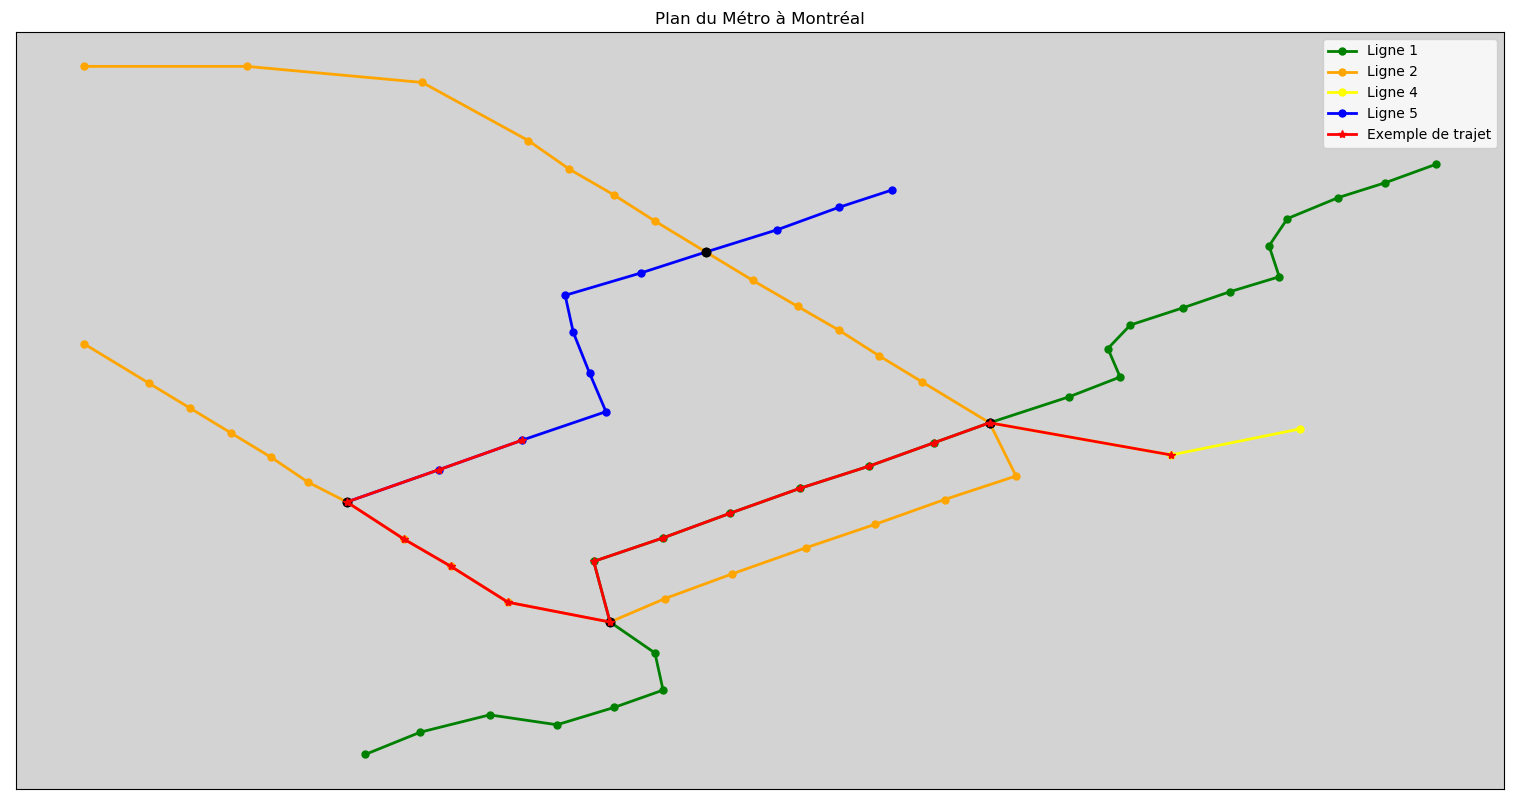

In [31]:
display(Image("images/Exemple 2 Trajet 1.png", width=1200), Image("images/Exemple 2 Trajet 2.png", width=1200), Image("images/Exemple 2 Trajet 3.png", width=1200))

___

## Répartition des passagers de manière pondérée sur le réseau ferroviaire

### Estimation du nombre de passagers par incrément de temps

Pour pouvoir effectuer la simulation du réseau de Montréal, nous allons effectuer les hypothèses suivantes :
- L'affluence du nombre d'usagers utilisant le réseau suit la même distribution que l'affluence du nombre de passagers sur la station la plus importante du réseau (ici, Berri-UQAM)
- On cherche à avoir le même nombre de passagers par jour que le chiffre moyen donné par la STM
- Les usagers apparaissent aléatoirement sur le réseau de Montréal, selon un critère de popularité des stations (voir plus haut)

L'objectif sera ensuite de comparer les temps réels de certaines stations avec les temps simulés, puis calculer l'écart moyen relatif (pourcentage) entre les temps simulés et les temps réels.

___

Un incrément de temps [tick] correspond à 30 secondes.
On a une approximation toutes les 30 minutes de l'affluence sur la station principale du réseau.
- On cherche à savoir le nombre de nouveaux passagers par incrément de temps sur l'ensemble du réseau
- 165.5 millions de passagers en 2021 annoncés par la STM en 2021
- 453 114 passagers par jour (en moyenne, $453 114 \sim \dfrac{165.5 * 10^6}{365.25}$)

On souhaite connaître $y$ tel que :

$$ \sum _{n \in I} k(n)y = 453 114 $$

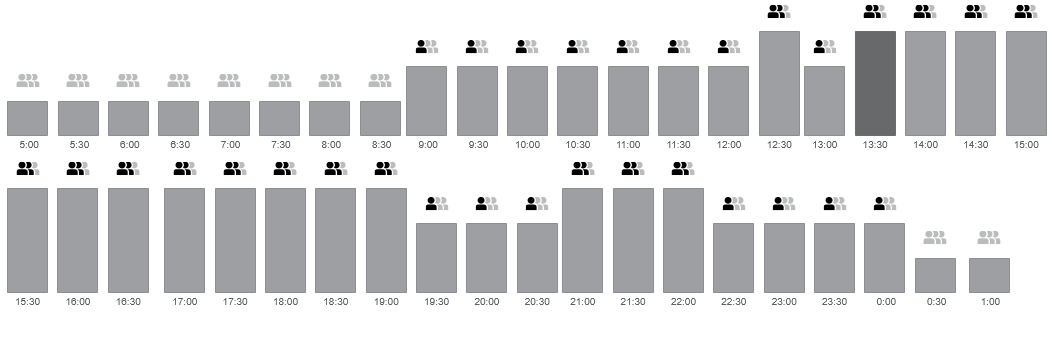

In [32]:
display(Image("images/Données fréquentation.png", width=600))

$\sum _{n \in I} k(n)y = 453114 \iff y = \dfrac{453114}{\sum _{n \in I} k(n)}$

On a :

$\sum _{n \in I} k(n) = \sum _{n \in I} 60 * j(n) $

Avec $k(n)$ le nombre d'incréments multiplié par le taux d'affluence pendant une période donnée, $j(n)$ le taux d'affluence pendant la période $n$

En effet, nombre d'incréments par période : $\dfrac{30 \text{minutes}}{30 \text{secondes}} = 60$

Donc :

$\sum _{n \in I} j(n) = 1*7 + 2*7 + 3 + 2 + 3*12 + 2*3 + 3*3 + 4*2 + 2*1$

$\sum _{n \in I} j(n) = 87$

Ainsi,

$$ y = \dfrac{453114}{\sum _{n \in I} k(n)} = \dfrac{453114}{87*60} \sim 86.80 $$

On prendra $y = 87$ pour la simulation.

___

In [33]:
L = [0]*60 + [87]*60*7 + [87*2]*60*7 + [87*3]*60 + [87*2]*60 + [87*3]*60*12 + [87*2]*60*3 + [87*3]*60*3 + [87*2]*60*4 + [87]*60*2

if lecteur:
    Y = open("donnees simulees.txt","r").read().split(",")
    Y = [int(v) for v in Y]
else :
    Y=simulation(L) #Génération de la simulation à partir de la liste du nombre de personnes
    with open("donnees simulees.txt", "w") as fichier:
        fichier.write(",".join(str(v) for v in Y))

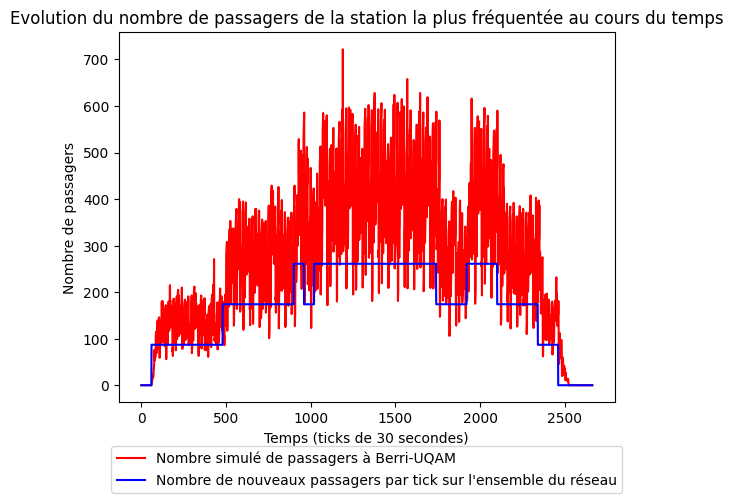

In [34]:
X = []
N = len(Y)
n = len(L)
for i in range(n,N):
    L.append(0)
for i in range(N):
    X.append(i+1)

plt.plot(X,Y,color='red',label='Nombre simulé de passagers à Berri-UQAM')
plt.plot(X,L,color='blue', label="Nombre de nouveaux passagers par tick sur l'ensemble du réseau")
plt.xlabel("Temps (ticks de 30 secondes)")
plt.ylabel("Nombre de passagers")
plt.legend(loc="upper center",bbox_to_anchor=(0.5,-0.1),fancybox=True)
plt.title("Evolution du nombre de passagers de la station la plus fréquentée au cours du temps")
plt.show()

Pour faciliter la comparaison, nous allons utiliser un moyenneur afin que le nombre de passagers simulé à la station Berri-UQAM (la plus fréquentée du réseau) soit plus facile à lire.

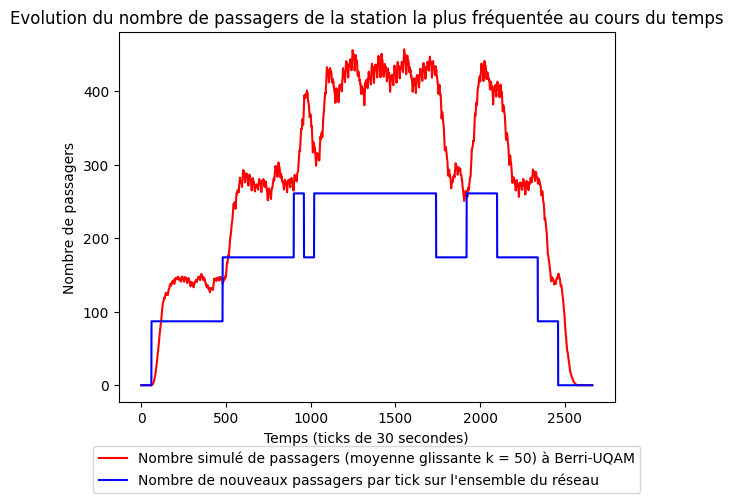

In [35]:
Y2 = moyenneur(Y,50)

plt.plot(X,Y2,color='red',label='Nombre simulé de passagers (moyenne glissante k = 50) à Berri-UQAM')
plt.plot(X,L,color='blue', label="Nombre de nouveaux passagers par tick sur l'ensemble du réseau")
plt.xlabel("Temps (ticks de 30 secondes)")
plt.ylabel("Nombre de passagers")
plt.legend(loc="upper center",bbox_to_anchor=(0.5,-0.1),fancybox=True)
plt.title("Evolution du nombre de passagers de la station la plus fréquentée au cours du temps")
plt.show()

Enfin, on ajuste d'un facteur $\alpha$ afin de superposer les lignes :

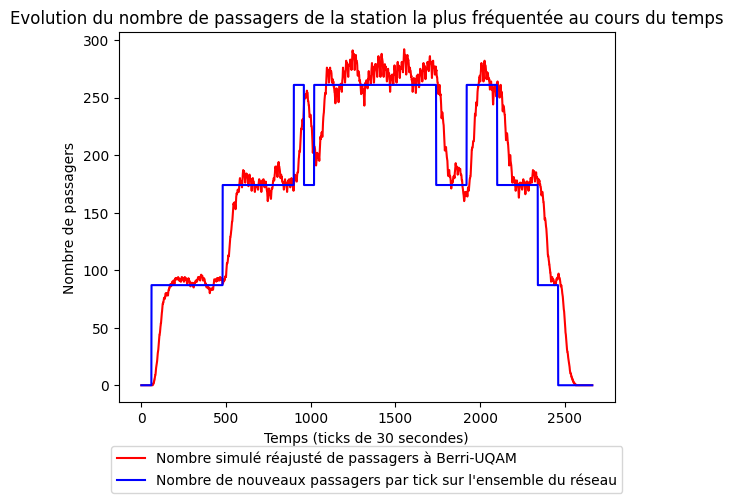

In [36]:
def multiplieur(L,alpha):
    R = []
    for elem in L:
        R.append(int(elem*alpha))
    return(R)

Y3 = multiplieur(Y2,0.64)
plt.plot(X,Y3,color='red',label='Nombre simulé réajusté de passagers à Berri-UQAM')
plt.plot(X,L,color='blue', label="Nombre de nouveaux passagers par tick sur l'ensemble du réseau")
plt.xlabel("Temps (ticks de 30 secondes)")
plt.ylabel("Nombre de passagers")
plt.legend(loc="upper center",bbox_to_anchor=(0.5,-0.1),fancybox=True)
plt.title("Evolution du nombre de passagers de la station la plus fréquentée au cours du temps")
plt.show()

On remarque que l'hypothèse de simulation est vérifiée :

La distribution des passagers sur l'ensemble du réseau suit bien la distribution des passagers en attente / l'affluence des passagers dans la station la plus fréquentée.
Cela peut se traduire par le fait que Berri-UQAM est la station centrale de transit du réseau de Montréal entre plusieurs lignes, et qu'ainsi les passagers ont tendance à s'y rendre pour effectuer des liaisons.

On peut de plus observer un phénomène intéressant, qui est celui du léger temps d'adaptation entre la distribution théorique et celle simulée, temps d'adaptation lié à l'inertie du réseau pour s'adapter à la nouvelle distribution.

___

### Analyse des résultats : précision de la simulation

L'objectif est maintenant d'établir des statistiques sur les temps de trajet simulés : le réseau obtenu artificiellement est-il proche de la réalité ?
Pour ce faire, nous obtenons après exécution de la simulation le fichier **Résultats.txt** contenant les stations de départ et d'arrivée, ainsi que les temps de transit, de tous les passagers du réseau sur une journée.

Nous comparons ensuite ces données avec les données réelles (nous n'utiliserons que les 10 trajets les plus fréquents pour établir les résultats).

In [37]:
temps_stations = dict()
with open("Résultats.txt", 'r') as f:
    for ligne in f:
        correspondance = re.search(r'Depart : (.*?) ; Arrivee : (.*?) ; Duree : (\d+)', ligne)
        if correspondance:
            depart, arrivee, duree = correspondance.groups()
            paire_stations = tuple(sorted((depart.strip(),arrivee.strip())))
            if paire_stations not in temps_stations:
                temps_stations[paire_stations] = []
            temps_stations[paire_stations].append(int(duree))

On trie selon le nombre de temps de trajet enregistré, et on extrait les 5 paires ayant le plus de trajet, et 5 paires au milieu de la liste. L'objectif est d'avoir à la fois des trajets courts (très fréquents autour du centre de la ville / du réseau) mais aussi des trajets plus longs pour évaluer la précision de la simulation.

In [38]:
temps_stations_trie = sorted(temps_stations.items(), key=lambda x: len(x[1]), reverse=True)
n_liste = len(temps_stations_trie) 
temps_stations_tests = temps_stations_trie[:5]+temps_stations_trie[n_liste//2:5+n_liste//2]
for (paire, durees) in temps_stations_tests:
    print(f"Stations: {paire[0]} - {paire[1]}, Nombre de trajets: {len(durees)}")

Stations: Berri-UQAM - McGill, Nombre de trajets: 1473
Stations: Berri-UQAM - Guy-Concordia (Guy), Nombre de trajets: 1402
Stations: Berri-UQAM - Bonaventure, Nombre de trajets: 1390
Stations: Bonaventure - McGill, Nombre de trajets: 1215
Stations: Guy-Concordia (Guy) - McGill, Nombre de trajets: 1185
Stations: Pie-IX - Villa-Maria, Nombre de trajets: 121
Stations: De L'Église - Jarry, Nombre de trajets: 121
Stations: Beaubien - Outremont, Nombre de trajets: 120
Stations: Acadie - De L'Église, Nombre de trajets: 120
Stations: Beaubien - Sauvé, Nombre de trajets: 119


Pour ces trajets, les données réelles (temps de transit en weekend entre les deux stations) sont les suivantes (données fournies par Google Map):

Il est important de prendre en compte le fait que les temps annoncés ne sont que les temps de transit, en ne comprenant pas le temps d'attente initial avant l'arrivée du premier train. On a une fréquence moyenne de passage de 9 minutes environ pour toutes les lignes, on ajoute donc 9 ticks (4 minutes 30) à chaque temps réel pour prendre en compte ce phénomène.

- Berri-UQAM - McGill : 4 minutes [8 ticks] $\rightarrow$ [17 ticks]
- Berri-UQAM - Guy-Concordia (Guy) : 6 minutes [12 ticks] $\rightarrow$ [21 ticks]
- Berri-UQAM - Bonaventure : 6 minutes [12 ticks] $\rightarrow$ [21 ticks]
- Bonaventure - McGill : 17 minutes [34 ticks] $\rightarrow$ [43 ticks]
- Guy-Concordia (Guy) - McGill : 3 minutes [6 ticks] $\rightarrow$ [15 ticks]
- Pie-IX - Villa-Maria : 34 minutes [68 ticks] $\rightarrow$ [77 ticks]
- De L'Église - Jarry : 33 minutes [66 ticks] $\rightarrow$ [75 ticks]
- Beaubien - Outremont : 13 minutes [26 ticks] $\rightarrow$ [35 ticks]
- Acadie - De L'Église : 29 minutes [58 ticks] $\rightarrow$ [67 ticks]
- Beaubien - Sauvé : 5 minutes [10 ticks] $\rightarrow$ [19 ticks]


In [39]:
valeurs_cible = [17,21,21,43,15,77,75,35,67,19]
temps_stations_hist = temps_stations_tests.copy()
for i in range (len(temps_stations_tests)):
    paire, durees = temps_stations_tests[i]
    temps_stations_hist[i] = (paire, durees, valeurs_cible[i])

def trace_histogramme(L):
    valeur_cible = L[2]
    paire = L[0]
    valeurs = L[1]
    plt.figure(figsize=(10, 6))
    _,_,_ = plt.hist(valeurs, bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(x=valeur_cible, color='r', linestyle='--', label=f'Valeur cible: {valeur_cible}')
    plt.title('Distribution des temps de trajet entre {} et {}'.format(paire[0], paire[1]))
    plt.xlabel('Valeurs')
    plt.ylabel('Fréquence')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


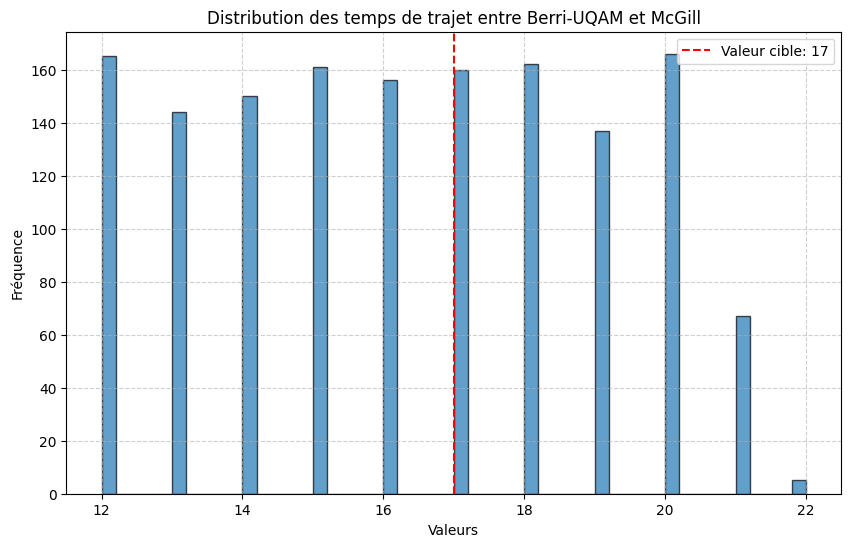

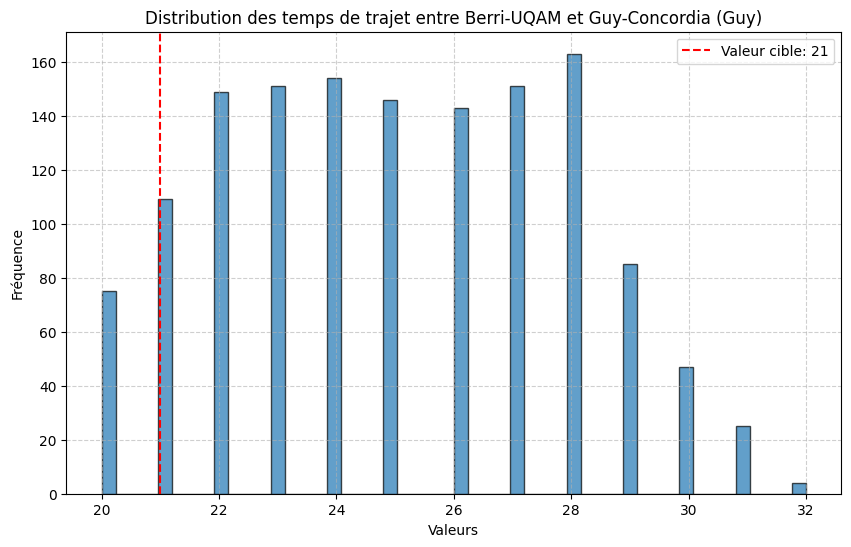

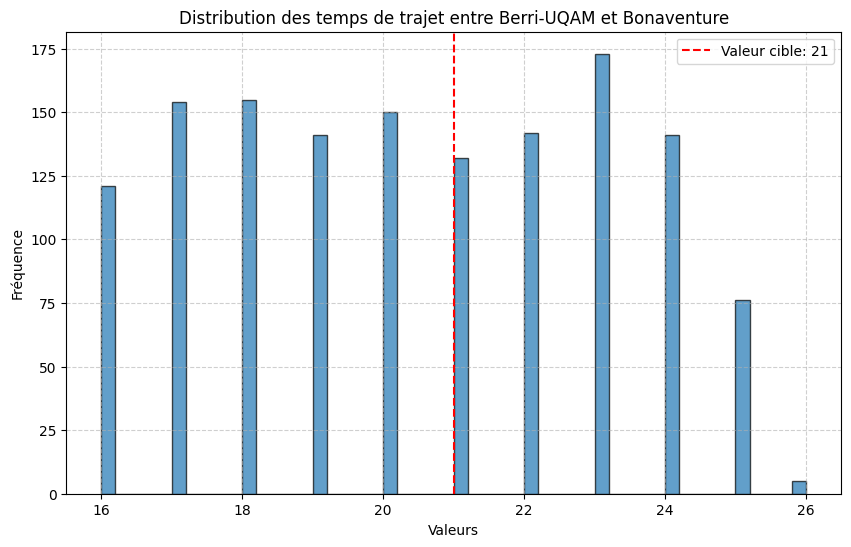

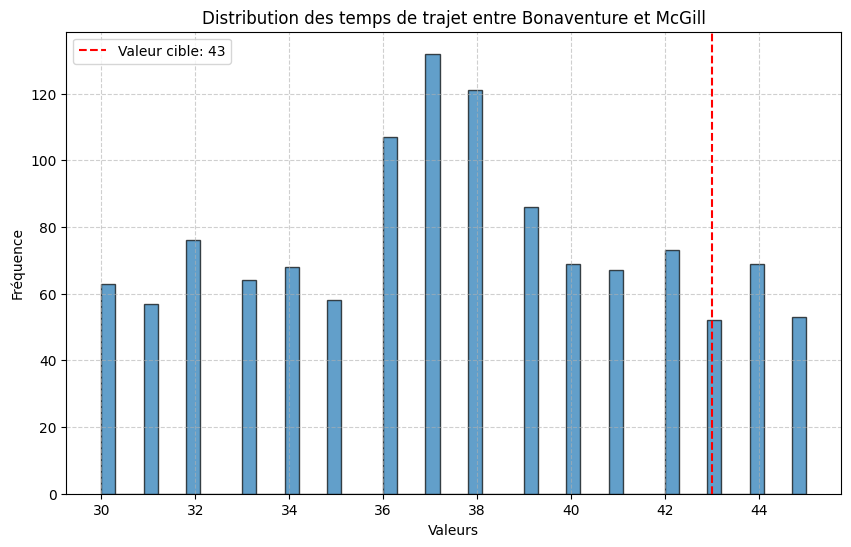

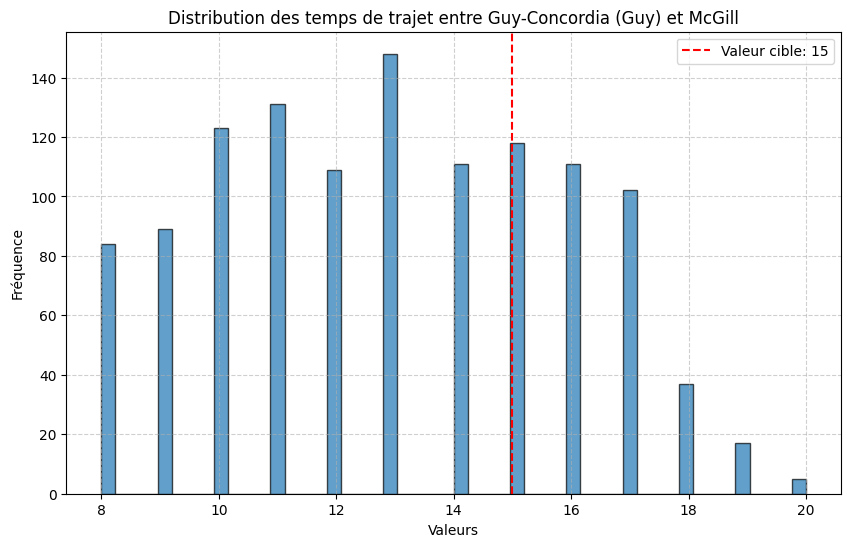

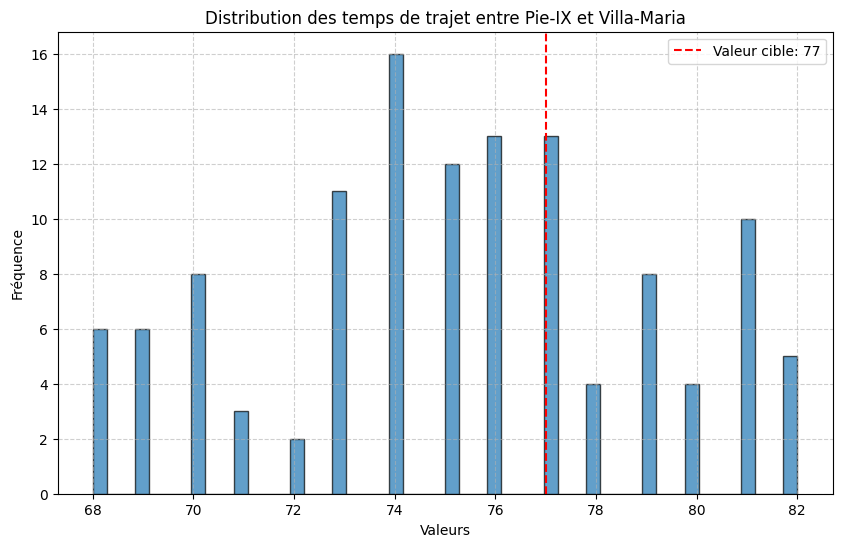

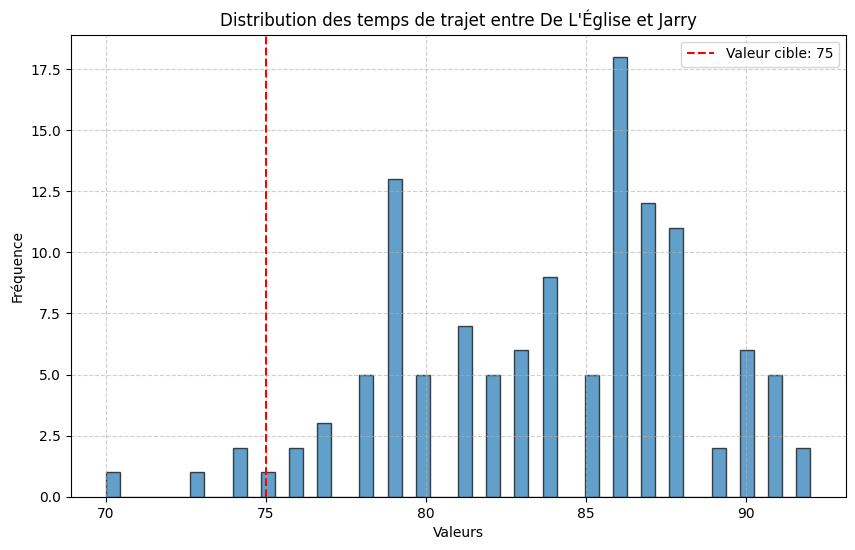

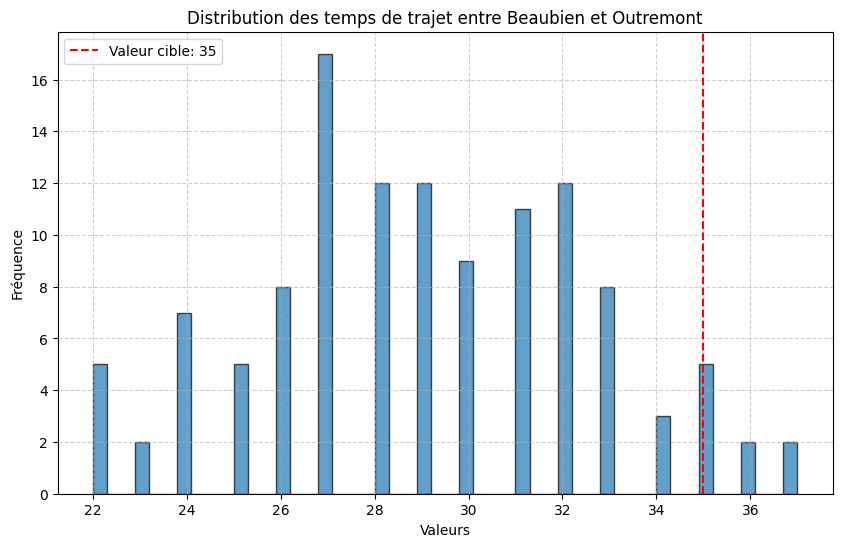

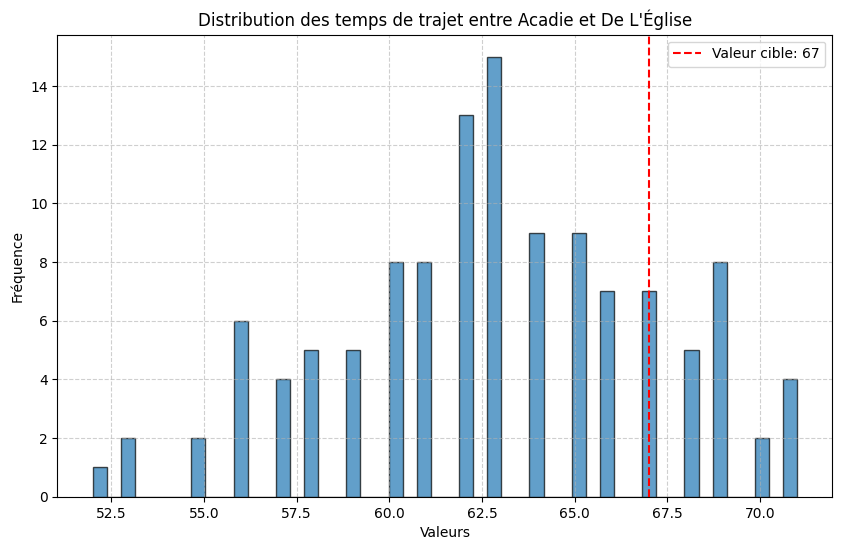

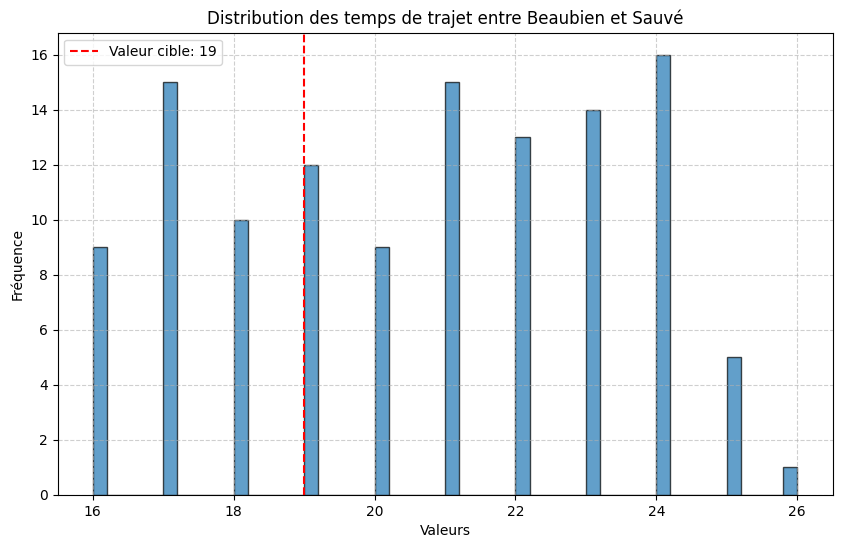

In [40]:
for L in temps_stations_hist:
    trace_histogramme(L)

Calcul de l'erreur relative entre les valeurs calculées et les valeurs exactes (précision du modèle):

In [41]:
ecart_relatif = 0
for i in range(len(temps_stations_hist)):
    ecart_relatif += abs(np.mean(temps_stations_hist[i][1]) - temps_stations_hist[i][2]) / temps_stations_hist[i][2]
print("Ecart relatif moyen :", ecart_relatif / len(temps_stations_hist))
    

Ecart relatif moyen : 0.09874593781961458


En général, les résultats sont assez proches, ou du moins raisonnablement éloignés des valeurs réelles. Nous n'observons pas de décalage aberrant entre les données simulées et les donées réelles. Nous pouvons de plus annoncer que **l'écart relatif moyen entre la simulation et les temps réels est inférieur à 10%**, ce qui est très satisfaisant.

### Le programme simule bien le réseau de Montréal, la simulation est satisfaisante.
___